# <b>세미1차_전화 해지 여부 분류
* https://dacon.io/competitions/official/236075/data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score, f1_score,  precision_score , recall_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import classification_report, confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>1. 데이터 불러오기

In [2]:
df = pd.read_csv(r"../Sammy_Project csv/train.csv")
# df_test = pd.read_csv(r"../Sammy_Project csv//test.csv")
# df_sample = pd.read_csv(r"../Sammy_Project csv/sample_submission.csv")

# <b> 2. 데이터 구조 및 구성 확인

## 2-1 데이터 크기 확인(shape)

In [3]:
df.shape

(30200, 14)

## 2-2 데이터 구조 확인(info)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       30200 non-null  object 
 1   가입일      30200 non-null  int64  
 2   음성사서함이용  30200 non-null  int64  
 3   주간통화시간   30200 non-null  float64
 4   주간통화횟수   30200 non-null  int64  
 5   주간통화요금   30200 non-null  float64
 6   저녁통화시간   30200 non-null  float64
 7   저녁통화횟수   30200 non-null  int64  
 8   저녁통화요금   30200 non-null  float64
 9   밤통화시간    30200 non-null  float64
 10  밤통화횟수    30200 non-null  int64  
 11  밤통화요금    30200 non-null  float64
 12  상담전화건수   30200 non-null  int64  
 13  전화해지여부   30200 non-null  int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 3.2+ MB


## 2-3 결측치 확인(isnull)
* 결측치 없음

In [5]:
df.isnull().sum()

ID         0
가입일        0
음성사서함이용    0
주간통화시간     0
주간통화횟수     0
주간통화요금     0
저녁통화시간     0
저녁통화횟수     0
저녁통화요금     0
밤통화시간      0
밤통화횟수      0
밤통화요금      0
상담전화건수     0
전화해지여부     0
dtype: int64

## 2-4 피쳐확인(columns)

In [6]:
df.columns

Index(['ID', '가입일', '음성사서함이용', '주간통화시간', '주간통화횟수', '주간통화요금', '저녁통화시간',
       '저녁통화횟수', '저녁통화요금', '밤통화시간', '밤통화횟수', '밤통화요금', '상담전화건수', '전화해지여부'],
      dtype='object')

## 2-5 형태 확인(describe)

In [7]:
df.describe()

,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
count,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000
mean,159.732649,12.037815,250.563457,159.175728,41.091447,263.247215,158.474536,25.394260,263.438285,157.047417,12.074648,2.288079,0.109868
std,123.752781,24.925334,84.403350,101.573057,23.179017,74.064922,102.200293,8.146126,73.778416,101.721601,9.414261,2.050746,0.312730
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,20.800000,20.000000,1.040000,0.000000,0.000000
25%,63.000000,0.000000,222.800000,88.000000,24.400000,223.700000,87.000000,22.220000,223.700000,87.000000,4.700000,2.000000,0.000000
50%,118.000000,1.000000,234.000000,117.500000,30.800000,243.000000,112.000000,23.320000,242.800000,108.000000,9.080000,2.000000,0.000000
75%,228.000000,22.000000,289.600000,223.000000,45.900000,290.300000,223.000000,28.820000,290.500000,222.000000,20.290000,2.000000,0.000000
max,2212.000000,1112.000000,481.900000,489.000000,118.600000,481.600000,489.000000,49.980000,481.800000,490.000000,44.980000,11.000000,1.000000


In [8]:
df.columns

Index(['ID', '가입일', '음성사서함이용', '주간통화시간', '주간통화횟수', '주간통화요금', '저녁통화시간',
       '저녁통화횟수', '저녁통화요금', '밤통화시간', '밤통화횟수', '밤통화요금', '상담전화건수', '전화해지여부'],
      dtype='object')

## 2-6 중복값확인(duplicated)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head(5)

,ID,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
0,TRAIN_00000,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,TRAIN_00001,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,TRAIN_00002,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0
3,TRAIN_00003,223,1,221.4,223,25.1,233.0,61,23.90,203.8,234,9.36,0,0
4,TRAIN_00004,222,0,96.3,222,28.7,223.9,69,28.08,263.1,223,2.80,8,0


### 중복/고유값/상수 컬럼(정보 없는 변수) 탐지

In [11]:
dup_rows = df.duplicated().sum()
print("중복 행 개수:", dup_rows)

# 고유값 개수
nunique = df.nunique(dropna=False).sort_values()
display(nunique.head(30))

# 상수 컬럼/거의 상수 컬럼 후보
const_cols = nunique[nunique <= 1].index.tolist()
near_const_cols = nunique[(nunique > 1) & (nunique <= 2)].index.tolist()

print("상수 컬럼:", const_cols)
print("거의 상수(고유값 2개) 후보:", near_const_cols[:20])

중복 행 개수: 0


전화해지여부         2
상담전화건수        11
음성사서함이용       76
밤통화횟수        233
주간통화횟수       239
저녁통화횟수       241
가입일          345
주간통화요금       735
밤통화요금       1216
저녁통화요금      1840
밤통화시간       2545
저녁통화시간      2606
주간통화시간      2771
ID         30200
dtype: int64

상수 컬럼: []
거의 상수(고유값 2개) 후보: ['전화해지여부']


# 3 컬럼명 바꾸기

In [12]:
original_columns = df.columns.tolist() #원본 컬럼 백업 

# 컬럼명 바꾸기
col_rename_map = {
    'ID': 'id',
    '전화해지여부': 'target', #컬럼이 분석하려고하는 주제에 어떤 영향을 주는지 각주처리 ex.주간통화시간 해지고객과 연관성 적음, 상담전화건수는 해지고객과 상당한 밀접이잇다 ....도메인지식
    '가입일': 'tenure',
    '음성사서함이용': 'vm_count',

    '주간통화시간': 'day_minutes',
    '주간통화횟수': 'day_calls',
    '주간통화요금': 'day_charge',

    '저녁통화시간': 'eve_minutes',
    '저녁통화횟수': 'eve_calls',
    '저녁통화요금': 'eve_charge',

    '밤통화시간': 'night_minutes',
    '밤통화횟수': 'night_calls',
    '밤통화요금': 'night_charge',

    '상담전화건수': 'cs_calls'
}
# 컬럼명 변환
df = df.rename(columns=col_rename_map)

print(df.columns.tolist())

['id', 'tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge', 'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes', 'night_calls', 'night_charge', 'cs_calls', 'target']


# 4 분석 전 불필요한 id제거

In [13]:
df = df.drop(columns=['id'])

In [14]:
print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (30200, 13)


,tenure,vm_count,day_minutes,day_calls,day_charge,eve_minutes,eve_calls,eve_charge,night_minutes,night_calls,night_charge,cs_calls,target
0,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0
3,223,1,221.4,223,25.1,233.0,61,23.90,203.8,234,9.36,0,0
4,222,0,96.3,222,28.7,223.9,69,28.08,263.1,223,2.80,8,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30200 non-null  int64  
 1   vm_count       30200 non-null  int64  
 2   day_minutes    30200 non-null  float64
 3   day_calls      30200 non-null  int64  
 4   day_charge     30200 non-null  float64
 5   eve_minutes    30200 non-null  float64
 6   eve_calls      30200 non-null  int64  
 7   eve_charge     30200 non-null  float64
 8   night_minutes  30200 non-null  float64
 9   night_calls    30200 non-null  int64  
 10  night_charge   30200 non-null  float64
 11  cs_calls       30200 non-null  int64  
 12  target         30200 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 3.0 MB


None

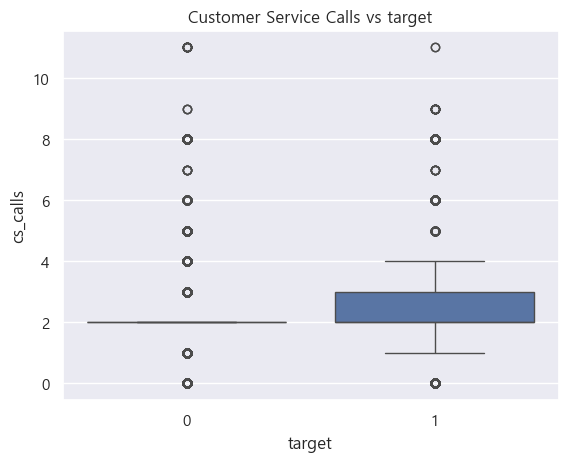

In [15]:
sns.boxplot(x='target', y='cs_calls', data=df) # 표봤을 때 상담전화건수가 75퍼까지는 적은데 최대가 11인걸로봐서 이상치로 판단 제거보다는 robustscaler로 영향줄이거나 그대로 두기 추천
plt.title('Customer Service Calls vs target')
plt.show();


# <b>EDA  

### <b>타겟(churn) 분포 확인

In [16]:
print(df['target'].value_counts()) #타겟의 빈도수
print(df['target'].value_counts(normalize=True)) # 타겟의비율

target
0    26882
1     3318
Name: count, dtype: int64
target
0    0.890132
1    0.109868
Name: proportion, dtype: float64


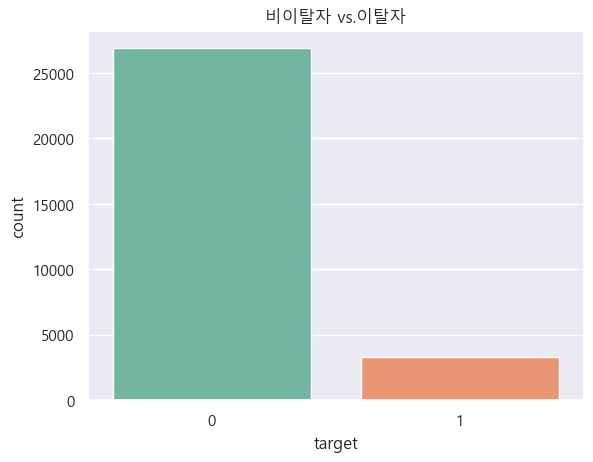

In [17]:
sns.countplot(x='target', data=df, palette='Set2')
plt.title('비이탈자 vs.이탈자')
plt.show();

### 수치형 분포(히스토그램) + 왜도/첨도 표

,feature,skew,kurtosis
1,vm_count,10.159494,378.258369
0,tenure,3.106704,39.885231
12,target,2.495178,4.226195
11,cs_calls,1.554562,2.402749
10,night_charge,1.276195,1.330879
4,day_charge,1.193922,0.024647
9,night_calls,0.808396,0.315923
6,eve_calls,0.801134,0.286689
8,night_minutes,0.782545,2.088991
5,eve_minutes,0.768130,2.088177


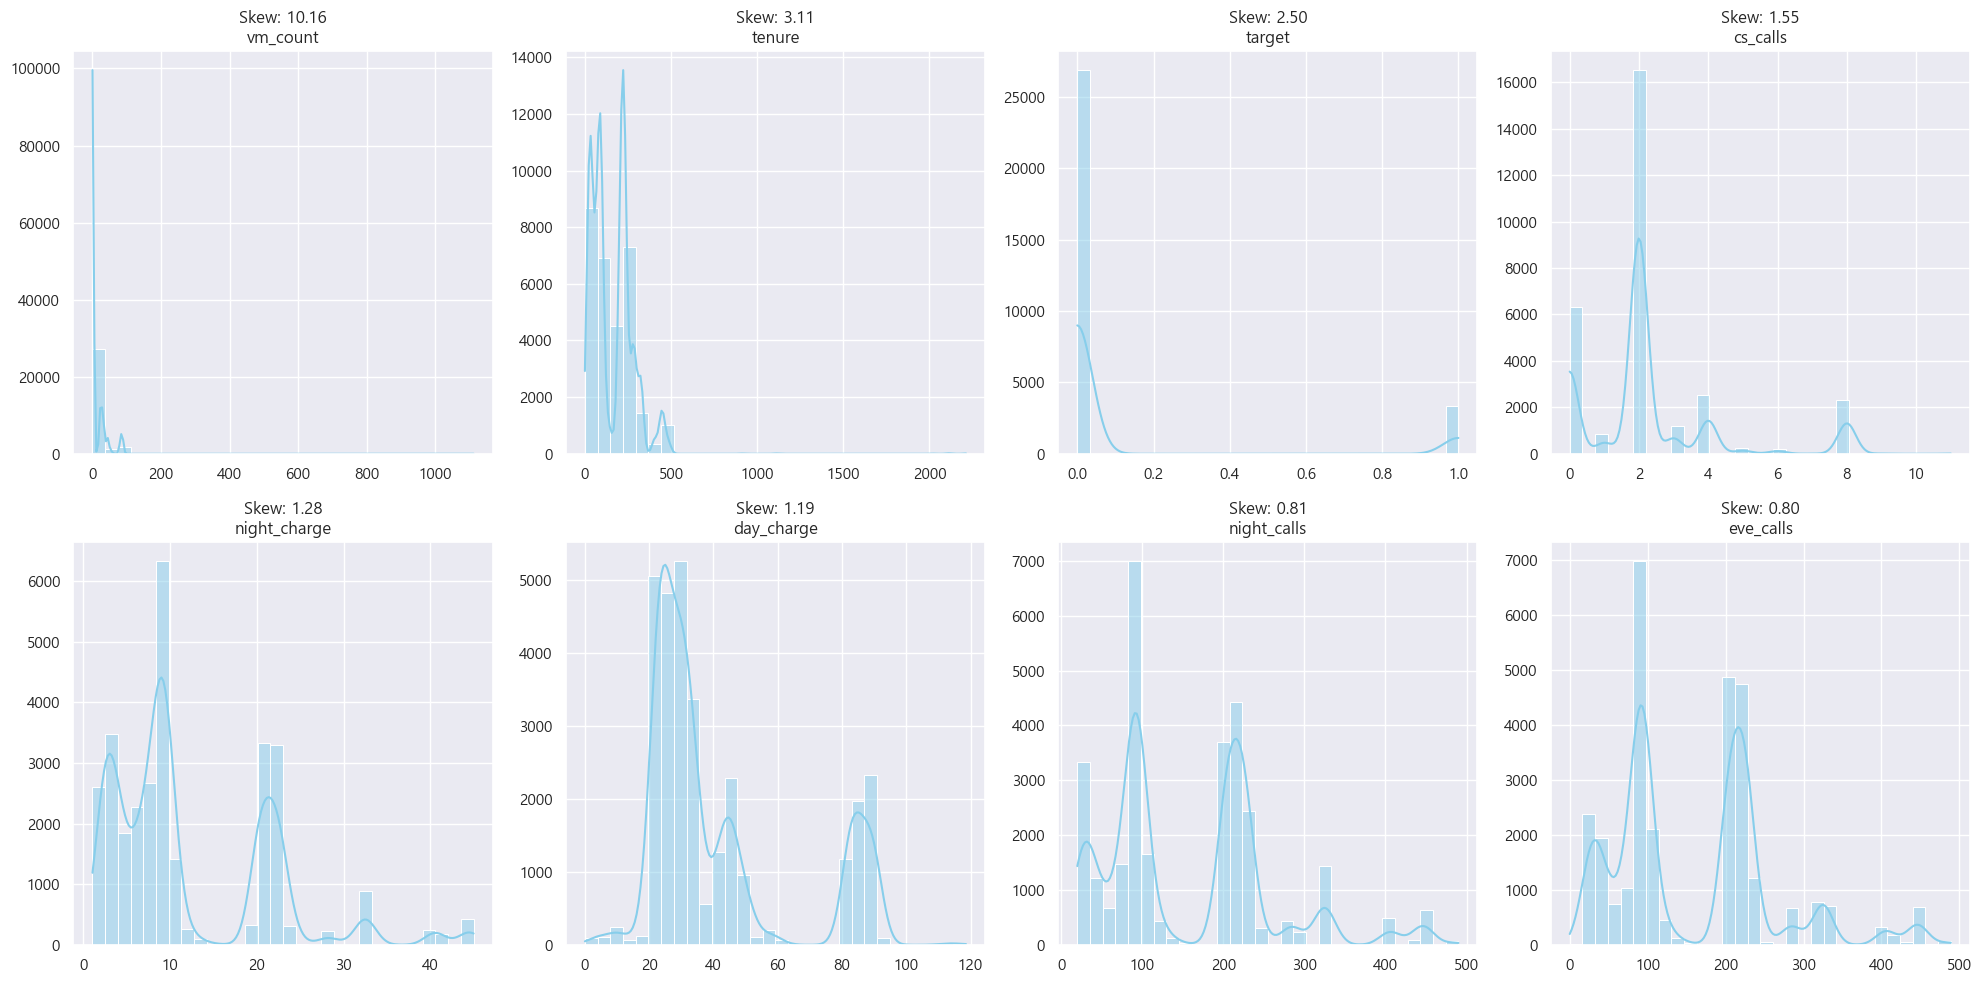

In [18]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("churn", errors="ignore") #왜도/첨도는 수치형 변수에만 의미있어서 수치형 컬럼만 선택
skew_kurt = [] #왜도 & 첨도 계산
for c in numeric_cols:
    x = df[c].dropna()
    skew_kurt.append((c, x.skew(), x.kurtosis()))

skew_kurt_df = pd.DataFrame(skew_kurt, columns=["feature","skew","kurtosis"]).sort_values("skew", key=np.abs, ascending=False) #절대값 기준으로 왜도 기준 정렬
display(skew_kurt_df.head(20))

#  차트(그리드 배치)
top_skew = skew_kurt_df["feature"].head(8).tolist()

# 왜도 큰 상위 변수 분포 확인
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() 

# 차트
for i, c in enumerate(top_skew):
    sns.histplot(df[c], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Skew: {df[c].skew():.2f}\n{c}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# 차트 보기쉽게수정한거라 신경안써도됨둥
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout();
plt.show();

# 상관/다중공선성/중복 정보 점검 (EDA 6단계)

In [19]:
# 히스토그램 수정해야함
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 이미지의 상관계수 상위 항목들을 기반으로 구성
# def plot_corr_hist(df, x_col, y_col):
#     plt.figure(figsize=(10, 6))
    
#     # 2D Histogram (밀도를 히트맵 형태의 히스토그램으로 시각화)
#     plt.hist2d(df[x_col], df[y_col], bins=30, cmap='Blues')
    
#     cb = plt.colorbar()
#     cb.set_label('Counts in Bin')
    
#     plt.title(f"2D Histogram: {x_col} vs {y_col}", fontsize=15)
#     plt.xlabel(x_col)
#     plt.ylabel(y_col)
#     plt.show()

# # 1. 상관계수 0.582인 변수 쌍
# plot_corr_hist(df, 'eve_minutes', 'eve_charge')

# # 2. 상관계수 0.403인 변수 쌍
# plot_corr_hist(df, 'eve_charge', 'night_minutes')

<Figure size 1200x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Spearman Correlation Heatmap (numeric)')

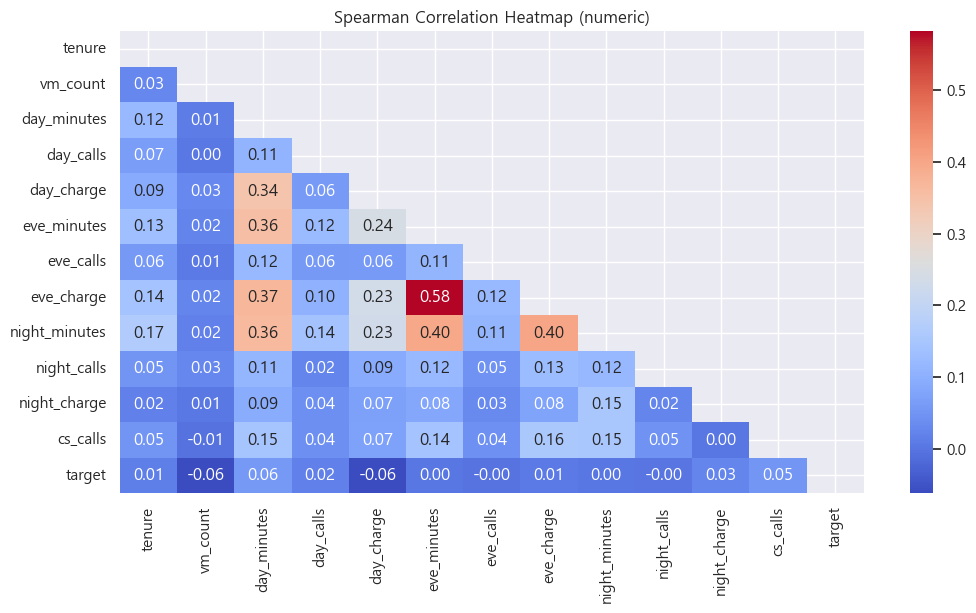

eve_minutes    eve_charge       0.582299
eve_charge     night_minutes    0.403082
eve_minutes    night_minutes    0.398314
day_minutes    eve_charge       0.368581
               night_minutes    0.362238
               eve_minutes      0.355500
               day_charge       0.342345
day_charge     eve_minutes      0.244269
               eve_charge       0.233863
               night_minutes    0.231133
tenure         night_minutes    0.166343
eve_charge     cs_calls         0.156312
night_minutes  night_charge     0.152996
               cs_calls         0.150583
day_minutes    cs_calls         0.146141
tenure         eve_charge       0.144204
eve_minutes    cs_calls         0.143594
day_calls      night_minutes    0.141643
tenure         eve_minutes      0.132276
eve_charge     night_calls      0.125515
dtype: float64

In [20]:
corr = df[numeric_cols].corr(method="spearman")  # 스피어만 상관계수 계산 순위 기반 상관계수 비정규분포랑 이상치에 덜 민감하다
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap (numeric)")
plt.show();  # 히트맵 => eve_charge-day_charrge : 하루 시간대별 요금 / night_minutes-night_charge : 사용시간과 요금

# 상관 높은 쌍 TOP 20 추출(중복 제거)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.abs().stack().sort_values(ascending=False).head(20)
display(high_pairs)

### 이상치(IQR) 비율 산출 + Boxplot

,feature,outlier_rate(IQR)
4,day_charge,0.186126
2,day_minutes,0.158146
7,eve_charge,0.134934
5,eve_minutes,0.113808
8,night_minutes,0.113079
1,vm_count,0.059371
6,eve_calls,0.027417
9,night_calls,0.026589
3,day_calls,0.026490
10,night_charge,0.014106


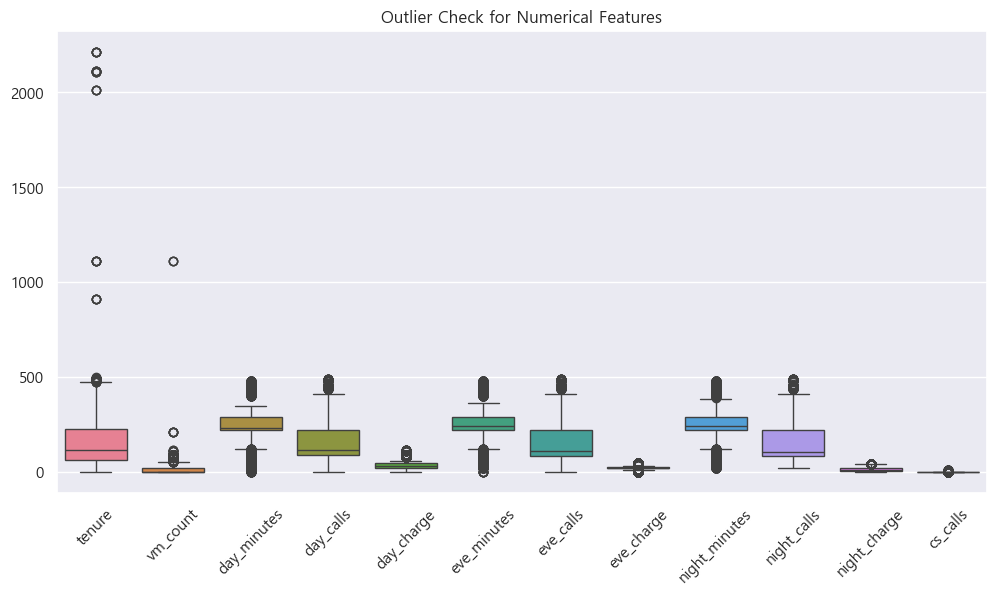

In [21]:
# 이상치 비율계산
out_tbl = [] #수치형 변수 반복
for c in numeric_cols:
    x = df[c].dropna() #해당 변수 결측치 제거
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        out_rate = 0.0 # iqr 0이면 이상치 없음
    else:
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr # 이상치 범위 설정
        out_rate = ((x < lo) | (x > hi)).mean() # 이상치 비율 계산
    out_tbl.append((c, out_rate))

out_df = pd.DataFrame(out_tbl, columns=["feature","outlier_rate(IQR)"]).sort_values("outlier_rate(IQR)", ascending=False) # 이상치 많은 변수대로 정렬
display(out_df.head(20))

# 이상치 Boxplot 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=[ 'target']))
plt.xticks(rotation=45)
plt.title('Outlier Check for Numerical Features')
plt.show();

## 타겟 중심 EDA
*  KDE(분포 차이) + boxplot(중앙/이상치 차이)

,feature,mean_diff(1-0),cohens_d,abs_d
4,day_charge,-5.262819,-0.243873,0.243873
1,vm_count,-5.000058,-0.224698,0.224698
11,cs_calls,0.374528,0.174399,0.174399
2,day_minutes,8.090089,0.097824,0.097824
10,night_charge,0.436891,0.046752,0.046752
3,day_calls,3.564272,0.035314,0.035314
0,tenure,2.646751,0.021664,0.021664
6,eve_calls,-1.397518,-0.013750,0.013750
9,night_calls,-1.015193,-0.010002,0.010002
8,night_minutes,-0.677588,-0.009537,0.009537


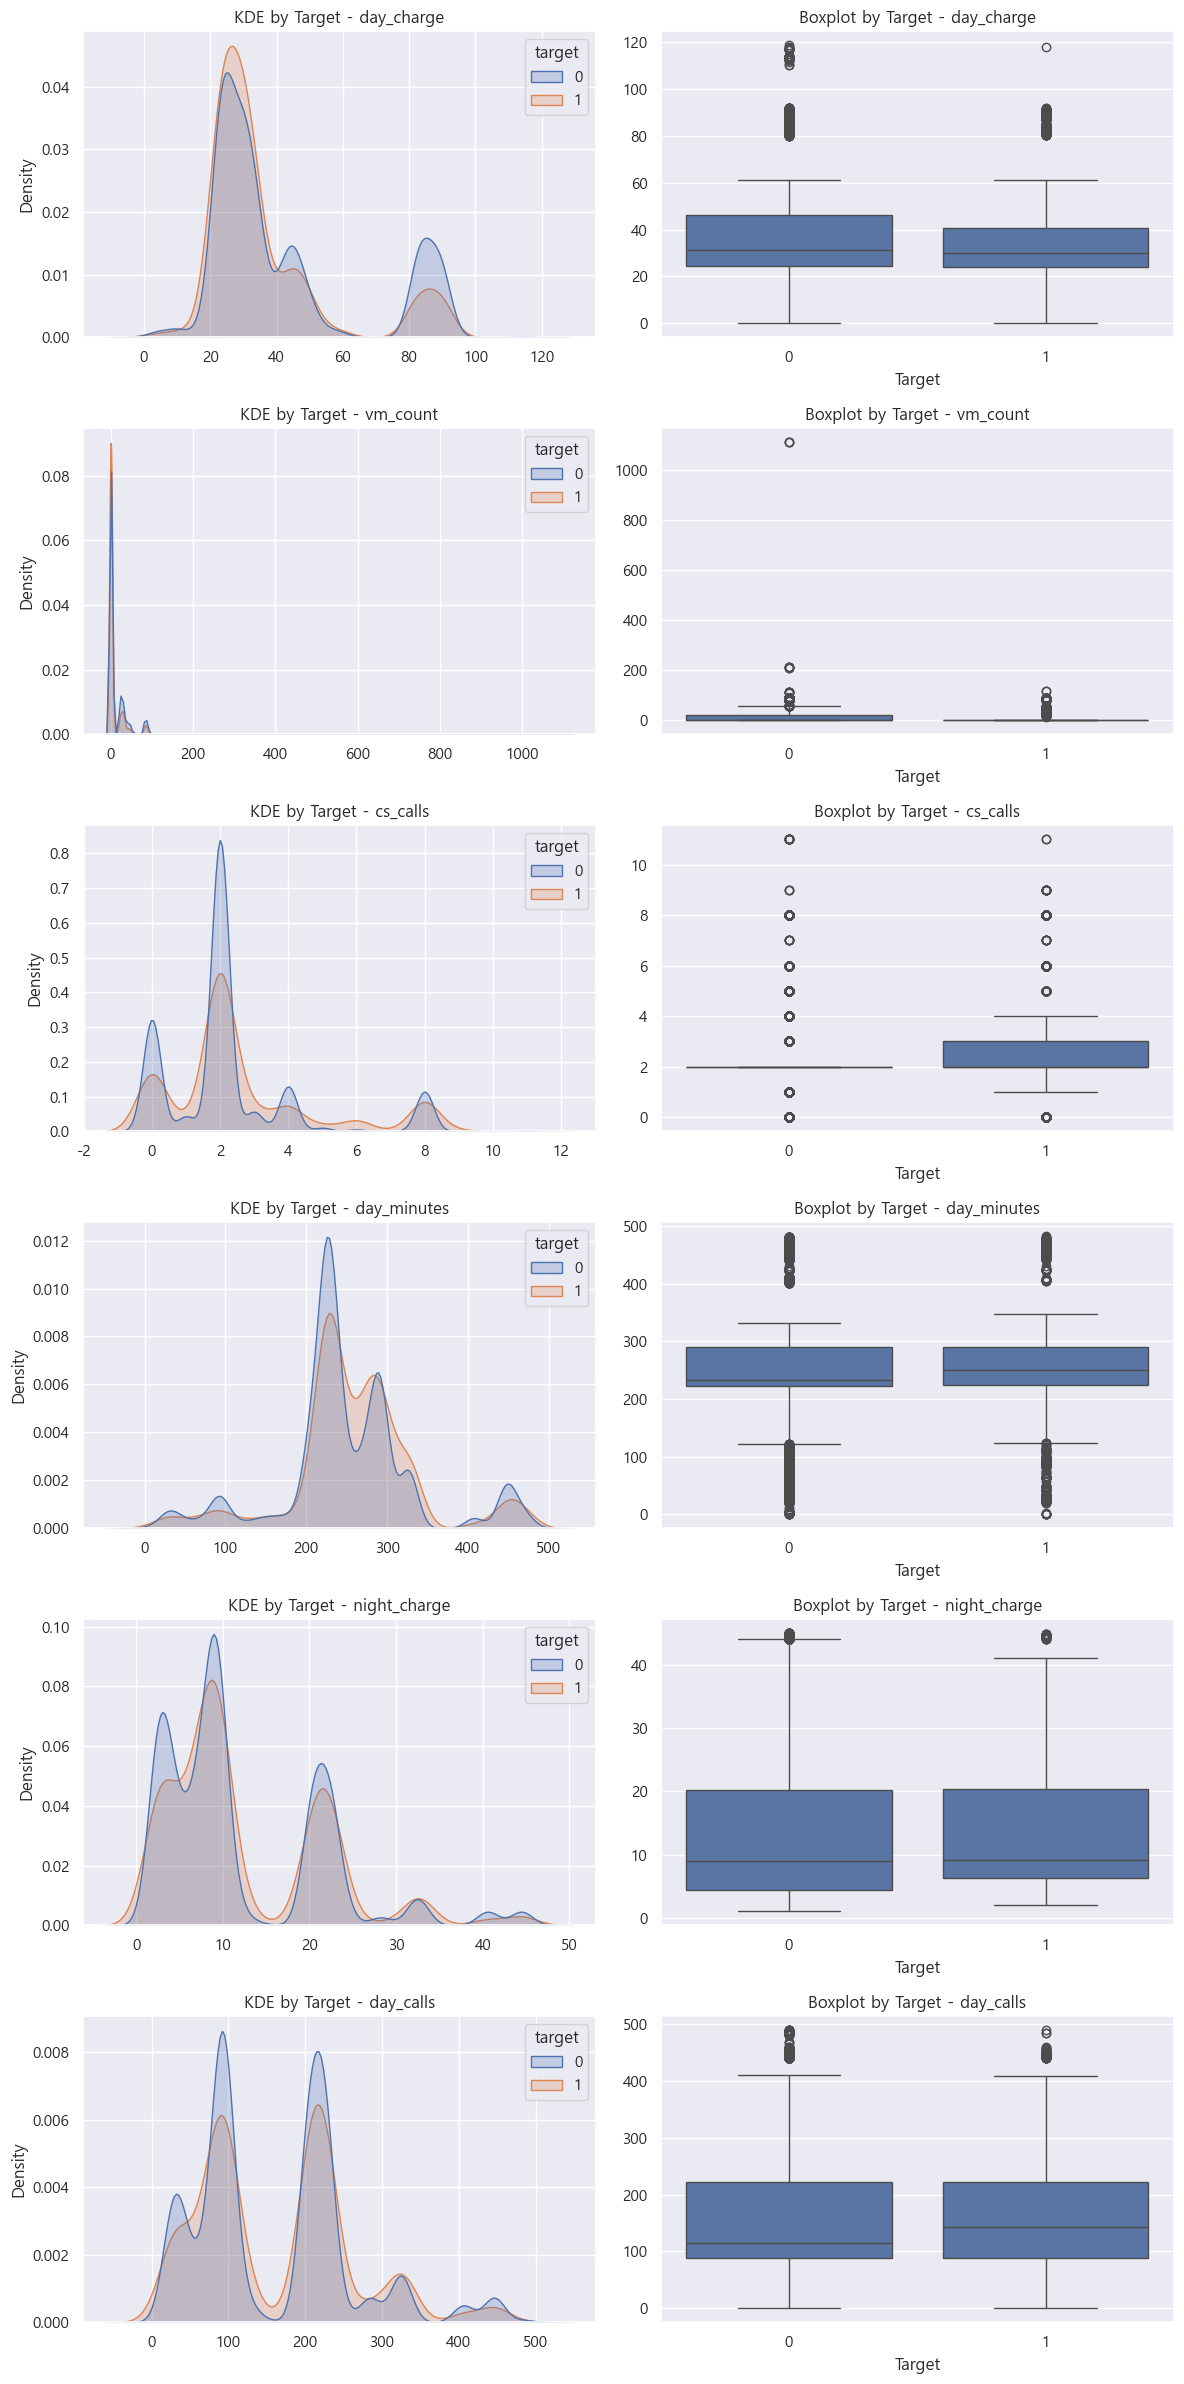

In [22]:
# 타깃에 따라 수치형 변수들이 얼마나 차이나는지 확인
def cohens_d(a, b): #두 그룹간 효과크기 계산함수 값이 클수록 그룹간 차이가 큼
    a = a.dropna(); b = b.dropna() #결측제거
    if len(a) < 2 or len(b) < 2:
        return np.nan #표본이 2개미만이면 분산 계산 불가로 결측처리
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if s == 0:
        return 0.0 #분산이 0이면 차이없음
    return (b.mean() - a.mean()) / s  # (target=1 - target=0)

rows = []
for c in numeric_cols:
    g0 = df.loc[df["target"]==0, c]
    g1 = df.loc[df["target"]==1, c] #타겟분리
    diff = g1.mean() - g0.mean() # 평균 차이 계산
    d = cohens_d(g0, g1)
    rows.append((c, diff, d, abs(d)))

num_target_df = pd.DataFrame(rows, columns=["feature","mean_diff(1-0)","cohens_d","abs_d"]) #데이터프레임 생성&정렬
num_target_df = num_target_df.sort_values("abs_d", ascending=False) #타겟과 가장 관계강한 변수 찾기
display(num_target_df.head(20))

# 상위 변수 시각화
top = num_target_df["feature"].head(6).tolist()

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 24))

for i, c in enumerate(top):
    
    # KDE Plot - 확률밀도 분포비교 - 겹치는 부분이 작을수록 변수와 타깃 간 관계가 강함
    sns.kdeplot(
        data=df, x=c, hue="target",
        fill=True, common_norm=False,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"KDE by Target - {c}", fontsize=12)
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Density")
    
    # Box Plot - 중앙값, 사분위수, 이상치 등으로 그룹 간 차이확인
    sns.boxplot(
        data=df, x="target", y=c,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot by Target - {c}", fontsize=12)
    axes[i, 1].set_xlabel("Target")
    axes[i, 1].set_ylabel("")

plt.tight_layout();
plt.show();

In [23]:
#df["target"].value_counts(normalize=True) # 타겟 불균형 -> smote, class_weight, f1, roc-auc

## 범주형: 타겟별 비율(Churn rate) + 막대그래프

,feature,top_categories,top_churn_rate
0,cs_calls,"[9, 6, 7, 5, 3]","[0.8333333333333334, 0.5517241379310345, 0.5384615384615384, 0.24786324786324787, 0.16440677966101694]"


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='cs_calls', ylabel='target'>

Text(0.5, 1.0, 'Top categories churn rate: cs_calls')

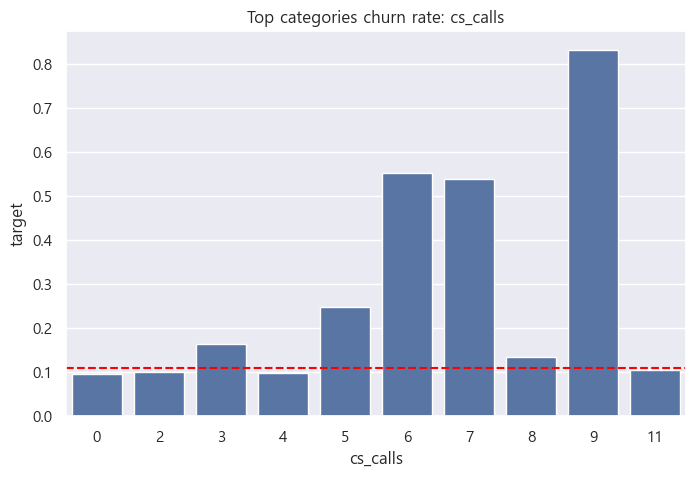

In [24]:
cat_cols = [col for col in df.columns if df[col].nunique() < 20] 
# col for col in df.columns if ~ : 조건에 맞는 컬럼만 담기
# df[col].nunique() < 20 : 데이터 타입이 정수나 실수여도 그룹가능
cat_cols = [c for c in cat_cols if c not in ["target", "ID"]] # target과 ID는 제외

cat_results = [] #상위 이탈률 테이블
for c in cat_cols:
    # 카테고리별 타겟=1 비율
    rate = df.groupby(c)["target"].mean().sort_values(ascending=False)
    cat_results.append((c, rate.index[:5].tolist(), rate.values[:5].tolist()))
display(pd.DataFrame(cat_results, columns=["feature","top_categories","top_churn_rate"]).head(20)) # 어떤 집단이 가장 위험한가 

# 특정 범주형 하나 선택 시각화 예시(상위 10개만)
if len(cat_cols) > 0:
    c = cat_cols[0]
    churn_rate = df.groupby(c)["target"].mean().sort_values(ascending=False).head(10).reset_index()
    
    plt.figure(figsize=(8,5))
    sns.barplot(data=churn_rate, x=c, y="target") #이탈의 임계점 시각화
    
    avg_churn = df["target"].mean() # 평균선
    plt.axhline(avg_churn, color='red', linestyle='--', label=f'Avg Churn ({avg_churn:.2f})')
    
    plt.title(f"Top categories churn rate: {c}")
    plt.show(); #그래프보면 고객센터랑 5번 이상 전화한 고객은 탈주함

In [25]:
def my_val(df):
    # 1) 타겟(정답) 벡터 y를 만든다: df에서 'target' 컬럼만 뽑음
    y = df['target']

    # 2) 입력 피처(설명변수) X를 만든다: target 컬럼을 제외한 나머지 컬럼들
    X = df.drop('target', axis=1)



    # 3) 학습/검증 데이터로 분리한다
    #    - test_size=0.2 : 전체의 20%를 검증용(X20,y20)으로 사용
    #    - random_state=42 : 매번 같은 분할이 나오게 고정(재현성)
    #    - stratify=y : 클래스 비율을 train/valid에 최대한 동일하게 맞춤(분류에서 중요)
    X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    

    

    # 4) 비교할 모델들을 리스트로 준비한다
    #    - RandomForest / XGBoost / LightGBM 3개 모델
    model_list = [
        RandomForestClassifier(random_state=42),
        XGBClassifier(random_state=42),
        LGBMClassifier(random_state=42, verbosity=-1)
    ]




    # 5) 모델을 하나씩 꺼내서 학습 -> 예측 -> 평가를 반복한다
    for model in model_list:

        # 5-1) 현재 모델 이름 출력 (리스트가 아니라 'model'의 클래스명!)
        print(f"\n{model.__class__.__name__} --------------------")

        # 5-2) 학습: train 데이터(X80,y80)로 모델을 fit
        model.fit(X80, y80)

        # 5-3) 예측: valid 데이터(X20)에 대해 클래스를 예측
        pred = model.predict(X20)

        # 5-4) 정확도(Accuracy) 계산: 전체 중 맞춘 비율
        accuracy = accuracy_score(y20, pred)

        # 5-5) 다중분류 precision/recall/f1은 average를 명시해야 안전하다
        #      macro: 각 클래스를 동일 가중치로 평균(불균형 데이터에서 유용)
        precision = precision_score(y20, pred, average='macro', zero_division=0)
        recall    = recall_score(y20, pred, average='macro', zero_division=0)
        f1        = f1_score(y20, pred, average='macro', zero_division=0)

        # 5-6) 한 줄 요약 출력
        print(f"accuracy : {accuracy:.4f}\tf1 : {f1:.4f}\trecall  : {recall:.4f}\tprecision : {precision:.4f}")

        # 5-7) 분류 리포트 출력(클래스별 precision/recall/f1/support)
        cr = classification_report(y20, pred, zero_division=0)
        print(cr)

        # 5-8) 혼동행렬(confusion matrix)
        #      labels를 고정값으로 두면 데이터에 없는 라벨이 섞일 수 있어
        #      실제 y에 존재하는 라벨만 사용하도록 만든다
        
        labels = sorted(y.unique())
        cm = confusion_matrix(y20, pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        print(cm_df)

In [26]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9144	f1 : 0.7094	recall  : 0.6622	precision : 0.8330
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5376
           1       0.74      0.34      0.47       664

    accuracy                           0.91      6040
   macro avg       0.83      0.66      0.71      6040
weighted avg       0.90      0.91      0.90      6040

      0    1
0  5298   78
1   439  225

XGBClassifier --------------------
accuracy : 0.9089	f1 : 0.6719	recall  : 0.6281	precision : 0.8259
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5376
           1       0.74      0.27      0.39       664

    accuracy                           0.91      6040
   macro avg       0.83      0.63      0.67      6040
weighted avg       0.90      0.91      0.89      6040

      0    1
0  5312   64
1   486  178

LGBMClassifier --------------------
accuracy : 0.8972	

In [ ]:
# 데이터 셋 카피
dfcp = df.copy()

SyntaxError: invalid syntax (978704672.py, line 2)

# log 변화 + 스케일링

In [ ]:
# 로그 변환할 컬럼명을 저장할 리스트
# ⚠ 현재는 빈 리스트라 실제로 로그변환이 아무 컬럼에도 적용되지 않음
col_list = []
# col_list에 있는 컬럼들에 대해 log(1+x) 변환 수행
# log1p는 0이 있어도 안전함 (log(1+0)=0)
# ⚠ col_list가 []이면 이 줄은 아무 효과 없음
dfcp[col_list] = np.log1p(dfcp[col_list])

# target 컬럼(정답)을 y로 분리
y = df["target"]
# target 컬럼을 제거한 나머지를 X(입력 피처)로 분리
X = df.drop(["target"], axis=1)



# 전체 데이터를 학습용(80%)과 검증용(20%)으로 분리
# stratify=y → 클래스 비율을 train/valid에 동일하게 유지
X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# 비교할 스케일러 3종
# StandardScaler → 평균 0, 표준편차 1
# MinMaxScaler → 0~1 범위로 변환
# RobustScaler → 중앙값 기반 (이상치에 강함)
scaler_list = [StandardScaler(), MinMaxScaler(), RobustScaler()]



# 비교할 모델 3종
# RandomForest → 배깅 기반 트리 앙상블
# XGB → 부스팅 기반 트리
# LGBM → 빠른 부스팅 기반 트리
model_list = [
    RandomForestClassifier(random_state=42),
    XGBClassifier(random_state=42),
    LGBMClassifier(random_state=42, verbosity=-1)
]



# 스케일러를 하나씩 꺼내 반복
for scaler in scaler_list:
    # 현재 사용 중인 스케일러 출력
    print()
    print(scaler)
    print("=====" * 50)
    # 모델을 하나씩 꺼내 반복
    for model in model_list:
        # 현재 모델 이름 출력
        print(f"\n{model.__class__.__name__}")
        # Pipeline 생성
        # 순서: scaler 적용 → model 학습
        pipeline = Pipeline([
            ("scaler", scaler),
            ("model", model)
        ])
        
        # 학습 데이터(X80, y80)로 학습
        # 이때 scaler도 train 기준으로 fit됨
        pipeline.fit(X80, y80)

        # 검증 데이터(X20)에 대해 예측 수행
        pred = pipeline.predict(X20)

        # 정확도 계산 (전체 중 맞춘 비율)
        accuracy = accuracy_score(y20, pred)

        # F1 점수 계산
        # average='macro' → 각 클래스를 동일 가중치로 평균
        # zero_division=0 → 분모 0 상황에서 0 처리
        f1 = f1_score(y20, pred, average='macro', zero_division=0)

        # 재현율 계산 (실제 값 중 맞춘 비율)
        recall = recall_score(y20, pred, average='macro', zero_division=0)

        # 정밀도 계산 (예측한 값 중 실제 정답 비율)
        precision = precision_score(y20, pred, average='macro', zero_division=0)

        # 성능 지표 출력 (소수점 4자리까지)
        print(f"accuracy : {accuracy:.4f} \t f1 : {f1:.4f}\t recall  : {recall:.4f} \t precision : {precision:.4f}")

# 실제 존재하는 라벨 값 정렬
labels = sorted(y.unique())
# 혼동행렬 계산 (정답 vs 예측 비교)
# ⚠ 여기 pred는 "마지막 모델 조합"의 예측값만 사용됨
cm = confusion_matrix(y20, pred, labels=labels)
# 혼동행렬을 보기 좋은 DataFrame 형태로 변환
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
# 혼동행렬 출력
print(cm_df)


# 교차검증

In [ ]:
# 교차검증 + 모델 비교 함수 정의
def my_skf(df):
# 각 모델의 f1 점수를 저장할 리스트
    score_list = []

    # StratifiedKFold 객체 생성
    # n_splits=5 → 데이터를 5등분
    # shuffle=True → 섞은 후 나눔
    # random_state=42 → 항상 동일하게 나뉘도록 고정
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



    # 타겟값 분리 (정답지)
    y = df["target"]
    # 설명변수(X) 생성 → target 컬럼 제거
    X = df.drop(["target"], axis=1)



    # -------------------------------
    # 여기서 train_test_split을 한 번 더 수행
    # 전체 데이터 중 20%를 테스트셋으로 분리
    # stratify=y → 클래스 비율 유지
    # -------------------------------
    X80, X20, y80, y20 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)




    # -------------------------------
    # StratifiedKFold 시작
    # 전체 데이터(X, y)를 5개 Fold로 나눔
    # -------------------------------
    for i, (train_index, test_index) in enumerate(skf.split(X, y)):

        # fold 기준 학습 데이터 생성
        X80 = X.iloc[train_index]

        # fold 기준 검증 데이터 생성
        X20 = X.iloc[test_index]

        # fold 기준 학습 정답
        y80 = y.iloc[train_index]

        # fold 기준 검증 정답
        y20 = y.iloc[test_index]



    # -------------------------------
    # 사용할 모델 리스트 정의
    # -------------------------------
    model_list = [
        RandomForestClassifier(random_state=42),   # 배깅 기반 앙상블 모델
        XGBClassifier(random_state=42),            # 부스팅 기반 모델
        LGBMClassifier(random_state=42, verbosity=-1)  # LightGBM 부스팅 모델
    ]




    # -------------------------------
    # 각 모델별 학습 및 평가 시작
    # -------------------------------
    for model in model_list:

        # 학습 데이터로 모델 학습
        model.fit(X80, y80)

        # 검증 데이터로 예측 수행
        pred = model.predict(X20)

        # 정확도 계산 (전체 맞춘 비율)
        accuracy = accuracy_score(y20, pred)

        # Macro F1 점수 계산
        # average='macro' → 클래스별 F1 평균
        f1 = f1_score(y20, pred, average='macro', zero_division=0)

        # Recall 계산 (실제 해지 중 맞춘 비율)
        recall = recall_score(y20, pred, average='macro', zero_division=0)

        # Precision 계산 (해지라고 예측한 것 중 진짜 해지 비율)
        precision = precision_score(y20, pred, average='macro', zero_division=0)

        # 각 모델 성능 출력
        print(f"accuracy : {accuracy:.4f} \t f1 : {f1:.4f}\t recall  : {recall:.4f} \t precision : {precision:.4f}")

        # f1 점수를 리스트에 저장
        score_list.append(f1)

    # 모델들의 평균 f1 점수 출력
    print(f"Fold 평균 점수 : {np.mean(score_list):.4f}")


# 그리드 서치

In [ ]:
# 함수 정의: df(데이터프레임)를 입력으로 받아 GridSearch 수행
def my_gsc(df):

    # 타겟값(정답)을 y로 분리
    y = df["target"]

    # target 컬럼을 제외한 나머지를 입력 변수 X로 분리
    X = df.drop(["target"], axis=1)

    # 사용할 모델 객체 생성 (예: 랜덤포레스트)
    # random_state는 결과 재현을 위한 고정값
    model = RandomForestClassifier(random_state=42)

        # 트리 개수 후보값 (많을수록 안정적이지만 느려짐)
        # 노드를 분할하기 위한 최소 샘플 수
        # 1은 허용되지 않음 (sklearn 규칙상 최소 2 이상)
    MYPARAM = { 
        "n_estimators" : [50, 100, 150],

        "min_samples_split" : [2, 3]
    }
    
    # StratifiedKFold 생성
    # n_splits=5 → 5등분 교차검증
    # stratified → 클래스 비율을 각 fold에 동일하게 유지
    # shuffle=True → 데이터 섞기
    # random_state → 섞는 기준 고정
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # train 점수도 저장 (과적합 확인용)
    gcv_model = GridSearchCV(
        model,                 # 사용할 모델
        param_grid=MYPARAM,    # 탐색할 하이퍼파라미터 조합
        scoring='f1_macro',    # 평가 기준 (다중분류 불균형에 적합)
        refit=True,            # 최적 파라미터로 전체 데이터 재학습
        cv=skf,                # 위에서 만든 5-fold 교차검증 사용
        return_train_score=True
    )
    
    # 전체 데이터에 대해 GridSearch 실행
    # 모든 파라미터 조합 × 5fold 수행 후 최고 조합 선택
    gcv_model.fit(X, y)

    # 교차검증 평균 점수 중 가장 높은 값 출력
    print("최고 점수", gcv_model.best_score_)

    # 최고 점수를 만든 하이퍼파라미터 조합 출력
    print("최적의 파라미터", gcv_model.best_params_)


In [ ]:
my_gsc(df)